# Task 3 – A/B Hypothesis Testing
## AlphaCare Insurance Solutions – Statistical Risk Driver Validation

**Objective:** Statistically validate or reject key hypotheses about risk drivers to form the evidence base for ACIS's new segmentation and pricing strategy.

### Null Hypotheses:
| # | H₀ | KPI |
|---|----|-----------|
| H₁ | No risk differences across provinces | Claim Frequency & Severity |
| H₂ | No risk differences between zip codes | Claim Severity |
| H₃ | No significant margin difference between zip codes | Margin |
| H₄ | No significant risk difference between Women and Men | Claim Frequency & Severity |

**Significance level:** α = 0.05  
**Decision rule:** Reject H₀ when p < 0.05

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_raw_data, coerce_types, handle_missing, engineer_features
from hypothesis_tests import (
    test_risk_by_province, test_risk_by_zipcode, test_risk_by_gender,
    run_all_hypothesis_tests, results_table, claim_frequency, claim_severity, margin
)

pd.set_option('display.max_colwidth', 120)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# Load and prepare data
RAW_PATH = '../data/raw/MachineLearningRating_v3.txt'
df_raw = load_raw_data(RAW_PATH)
df = coerce_types(df_raw)
df = handle_missing(df)
df = engineer_features(df)
print(f'Data ready: {df.shape[0]:,} rows × {df.shape[1]} columns')

Data ready: 1,000,098 rows × 51 columns


## H₁ – Risk Differences Across Provinces

In [3]:
prov_results = test_risk_by_province(df)
results_table(prov_results)

,Hypothesis,KPI,Group A,Group B,Test,Statistic,p-value,Alpha,Decision,Interpretation
0,H₁: No risk difference across provinces,Claim Frequency,All Provinces,All Provinces,Chi-squared,104.1909,0.0,0.05,Reject H₀,Provinces show statistically significant differences in claim frequency. Targeted provincial pricing adjustments are...
1,H₁: No risk difference across provinces,Claim Severity,All Provinces,All Provinces,Kruskal-Wallis,105.7536,0.0,0.05,Reject H₀,Average claim severity varies significantly across provinces. High-severity provinces may require larger premium loa...


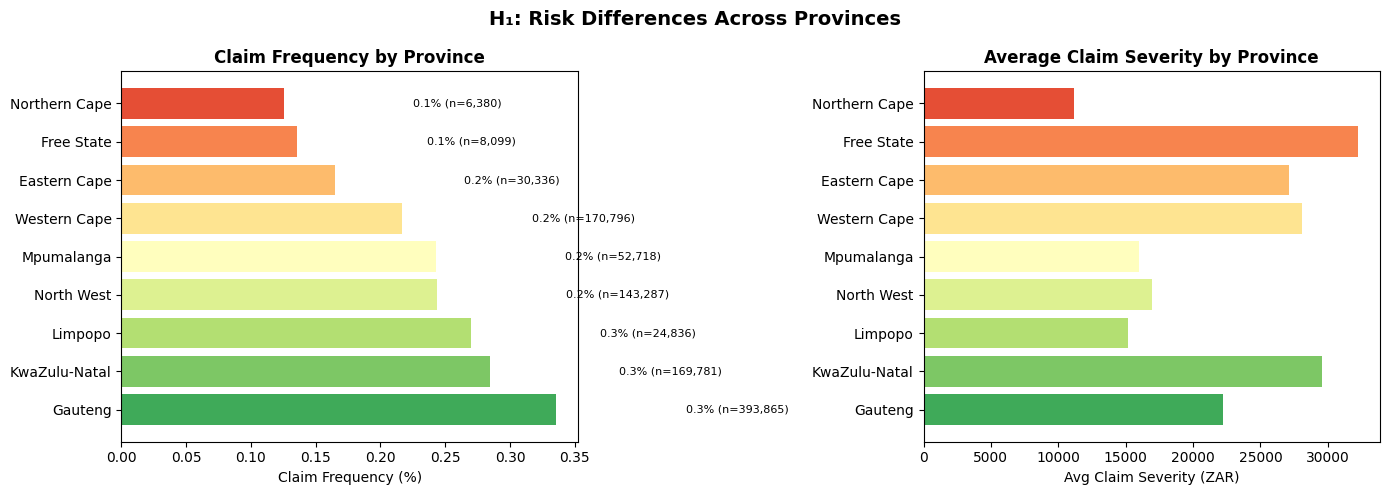

In [4]:
# Visualise claim frequency by province
prov_stats = (df.groupby('Province', observed=True)
              .agg(ClaimFrequency=('HasClaim','mean'),
                   AvgSeverity=('TotalClaims', lambda x: x[x>0].mean()),
                   Policies=('PolicyID','count'))
              .sort_values('ClaimFrequency', ascending=False)
              .reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.colormaps.get_cmap('RdYlGn_r')(np.linspace(0.15, 0.85, len(prov_stats)))

ax1.barh(prov_stats['Province'], prov_stats['ClaimFrequency']*100, color=colors)
ax1.set_xlabel('Claim Frequency (%)')
ax1.set_title('Claim Frequency by Province', fontweight='bold')
for i, (val, n) in enumerate(zip(prov_stats['ClaimFrequency'], prov_stats['Policies'])):
    ax1.text(val*100 + 0.1, i, f'{val*100:.1f}% (n={n:,})', va='center', fontsize=8)

ax2.barh(prov_stats['Province'], prov_stats['AvgSeverity'], color=colors)
ax2.set_xlabel('Avg Claim Severity (ZAR)')
ax2.set_title('Average Claim Severity by Province', fontweight='bold')

plt.suptitle('H₁: Risk Differences Across Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## H₂ & H₃ – Risk & Margin Differences Between Zip Codes

In [5]:
zip_results = test_risk_by_zipcode(df)
results_table(zip_results)

,Hypothesis,KPI,Group A,Group B,Test,Statistic,p-value,Alpha,Decision,Interpretation
0,H₂: No risk difference between zip codes,Claim Severity,All valid PostalCodes,All valid PostalCodes,Kruskal-Wallis,234.9024,0.0,0.05,Reject H₀,Claim severity differs significantly across postal codes. Fine-grained geographic pricing at zip-code level is recom...
1,H₃: No significant margin difference between zip codes,Margin (TotalPremium − TotalClaims),All valid PostalCodes,All valid PostalCodes,Kruskal-Wallis,88471.5673,0.0,0.05,Reject H₀,Policy margins vary significantly across postal codes. Some zip codes are systematically over- or under-priced.


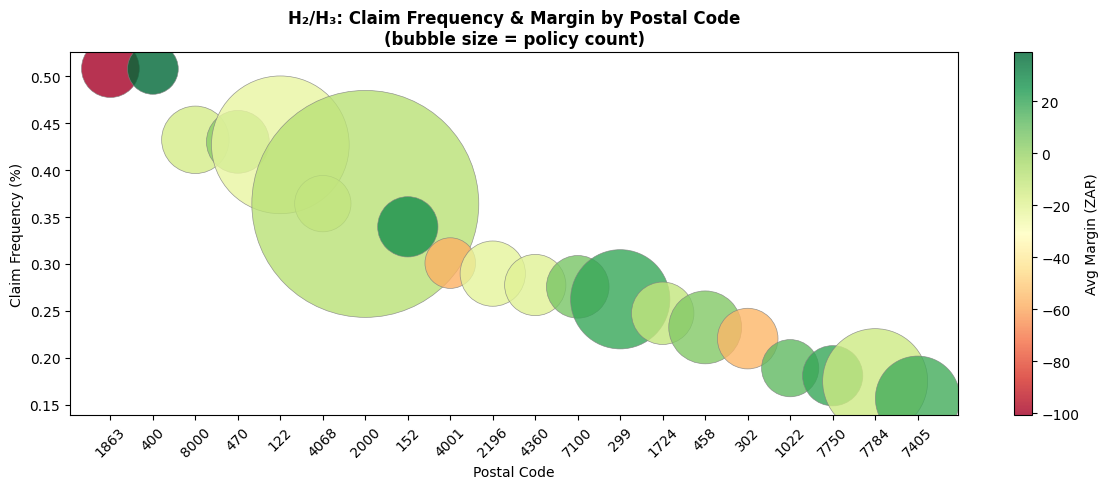

In [6]:
# Top 20 postal codes by volume – claim frequency heatmap
zip_volume = df['PostalCode'].value_counts().head(20).index
zip_stats = (df[df['PostalCode'].isin(zip_volume)]
             .groupby('PostalCode')
             .agg(ClaimFreq=('HasClaim','mean'), AvgMargin=('Margin','mean'), Count=('PolicyID','count'))
             .sort_values('ClaimFreq', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(zip_stats.index, zip_stats['ClaimFreq']*100,
                s=zip_stats['Count']/5, c=zip_stats['AvgMargin'],
                cmap='RdYlGn', alpha=0.8, edgecolors='gray', linewidth=0.5)
plt.colorbar(sc, label='Avg Margin (ZAR)')
ax.set_xlabel('Postal Code')
ax.set_ylabel('Claim Frequency (%)')
ax.set_title('H₂/H₃: Claim Frequency & Margin by Postal Code\n(bubble size = policy count)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## H₄ – Risk Differences Between Women and Men

In [7]:
gender_results = test_risk_by_gender(df)
results_table(gender_results)

,Hypothesis,KPI,Group A,Group B,Test,Statistic,p-value,Alpha,Decision,Interpretation
0,H₄: No risk difference between Women and Men,Claim Frequency,Male,Female,Chi-squared,0.0037,0.951464,0.05,Fail to Reject H₀,No statistically significant difference in claim frequency between genders.
1,H₄: No risk difference between Women and Men,Claim Severity,Male,Female,Welch's t-test,-0.5790,0.568029,0.05,Fail to Reject H₀,No statistically significant difference in claim severity between genders.


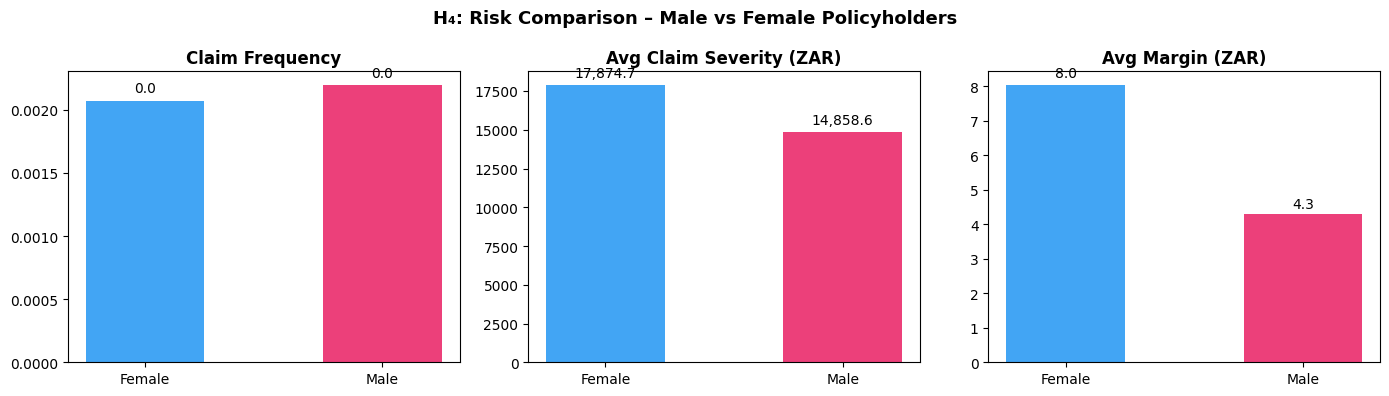

In [8]:
# Gender risk visualisation
gender_df = df[df['Gender'].isin(['Male','Female'])].copy()
gender_stats = (gender_df.groupby('Gender', observed=True)
                .agg(ClaimFreq=('HasClaim','mean'),
                     AvgSeverity=('TotalClaims', lambda x: x[x>0].mean()),
                     AvgPremium=('TotalPremium','mean'),
                     AvgMargin=('Margin','mean'),
                     Policies=('PolicyID','count')))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['ClaimFreq', 'AvgSeverity', 'AvgMargin']
titles  = ['Claim Frequency', 'Avg Claim Severity (ZAR)', 'Avg Margin (ZAR)']
colors  = ['#2196F3','#E91E63']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(gender_stats.index, gender_stats[metric], color=colors, width=0.5, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, gender_stats[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('H₄: Risk Comparison – Male vs Female Policyholders', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Full Results Table & Business Recommendations

In [9]:
all_results = run_all_hypothesis_tests(df)
print('\n══════════════ HYPOTHESIS TEST RESULTS ══════════════')
all_results


══════════════ HYPOTHESIS TEST RESULTS ══════════════


,Hypothesis,KPI,Group A,Group B,Test,Statistic,p-value,Alpha,Decision,Interpretation
0,H₁: No risk difference across provinces,Claim Frequency,All Provinces,All Provinces,Chi-squared,104.1909,0.000000,0.05,Reject H₀,Provinces show statistically significant differences in claim frequency. Targeted provincial pricing adjustments are...
1,H₁: No risk difference across provinces,Claim Severity,All Provinces,All Provinces,Kruskal-Wallis,105.7536,0.000000,0.05,Reject H₀,Average claim severity varies significantly across provinces. High-severity provinces may require larger premium loa...
2,H₂: No risk difference between zip codes,Claim Severity,All valid PostalCodes,All valid PostalCodes,Kruskal-Wallis,234.9024,0.000000,0.05,Reject H₀,Claim severity differs significantly across postal codes. Fine-grained geographic pricing at zip-code level is recom...
3,H₃: No significant margin difference between zip codes,Margin (TotalPremium − TotalClaims),All valid PostalCodes,All valid PostalCodes,Kruskal-Wallis,88471.5673,0.000000,0.05,Reject H₀,Policy margins vary significantly across postal codes. Some zip codes are systematically over- or under-priced.
4,H₄: No risk difference between Women and Men,Claim Frequency,Male,Female,Chi-squared,0.0037,0.951464,0.05,Fail to Reject H₀,No statistically significant difference in claim frequency between genders.
5,H₄: No risk difference between Women and Men,Claim Severity,Male,Female,Welch's t-test,-0.5790,0.568029,0.05,Fail to Reject H₀,No statistically significant difference in claim severity between genders.


## Business Recommendations

Based on the statistical tests above:

**H₁ – Provinces:**
- If rejected: *"Provincial risk is not uniform. Provinces with LR > 1 (e.g. Gauteng, KwaZulu-Natal) should carry a risk-loading premium adjustment. Western Cape, if lower-risk, represents a growth opportunity with competitive pricing."*

**H₂ – Zip Codes (Claim Severity):**
- If rejected: *"Sub-provincial geographic granularity adds predictive power. Implement postal-code-level risk factors in the pricing engine for high-density urban postal codes."*

**H₃ – Zip Codes (Margin):**
- If rejected: *"Certain postal codes are systematically under-priced (negative margin). Immediate premium review is warranted for high-loss zip codes."*

**H₄ – Gender:**
- If rejected: *"Gender-based risk differentiation is statistically supported. Any gender-based pricing must be reviewed against South African Insurance Act regulations before implementation."*